In [50]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

=== 1. 원본 데이터 정보 ===
전체 데이터 행 수: 78,702개

=== 2. 전처리 완료 ===
자치구 데이터 행 수: 75,675개
저장 위치: C:\Users\mbc1\Desktop\전처리완료_자치구_생활인구.csv


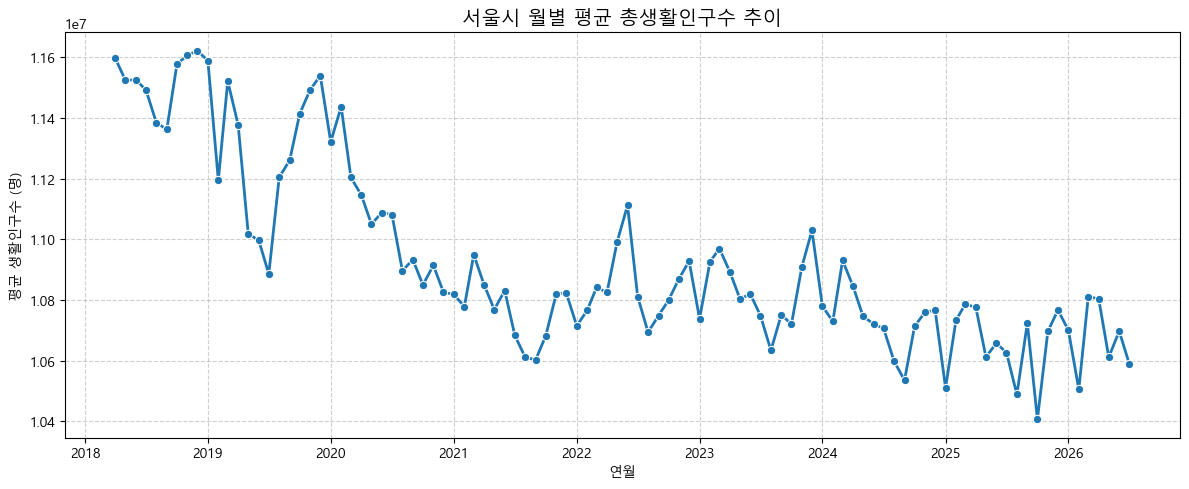

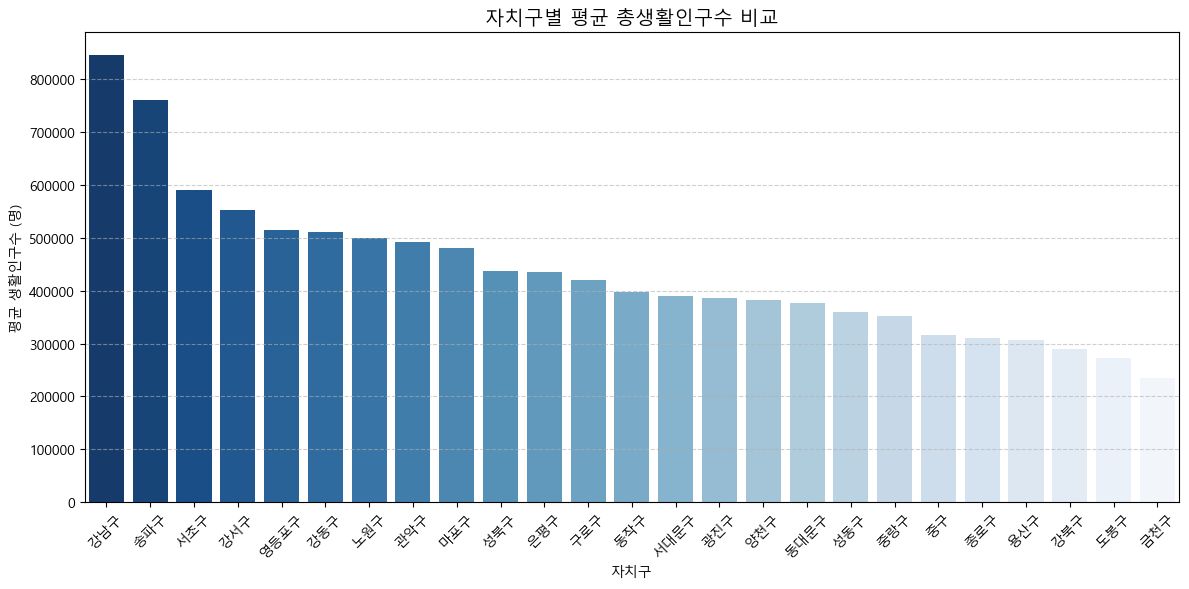

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 2. CSV 파일 로드 (한글 인코딩 대응)
file_path = r'C:\Users\mbc1\Desktop\자치구단위 서울생활인구 일별 집계표 (1).csv'

try:
    df = pd.read_csv(file_path, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='cp949')

print("=== 1. 원본 데이터 정보 ===")
print(f"전체 데이터 행 수: {len(df):,}개")

# 3. 데이터 전처리
# 3-1. 날짜 데이터 형변환 (20260731 -> 2026-07-31)
df['기준일'] = pd.to_datetime(df['기준일ID'].astype(str), format='%Y%m%d')

# 3-2. '서울시' 전체 합계 데이터와 25개 '자치구' 데이터 분리
df_district = df[df['시군구명'] != '서울시'].copy()  # 자치구 전용 데이터
df_seoul = df[df['시군구명'] == '서울시'].copy()        # 서울시 전체 데이터

# 3-3. 연월(Year-Month) 컬럼 생성
df_district['연월'] = df_district['기준일'].dt.to_period('M')
df_seoul['연월'] = df_seoul['기준일'].dt.to_period('M')

# 3-4. 전처리 완료된 자치구 데이터 저장
output_path = r'C:\Users\mbc1\Desktop\전처리완료_자치구_생활인구.csv'
df_district.to_csv(output_path, index=False, encoding='utf-8-sig')

print("\n=== 2. 전처리 완료 ===")
print(f"자치구 데이터 행 수: {len(df_district):,}개")
print(f"저장 위치: {output_path}")

# 4. 시각화 (그래프 시각화)

# [그래프 1] 월별 서울시 전체 평균 생활인구 추이
monthly_seoul = df_seoul.groupby('연월')['총생활인구수'].mean().reset_index()
monthly_seoul['연월'] = monthly_seoul['연월'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_seoul, x='연월', y='총생활인구수', marker='o', color='#1f77b4', linewidth=2)
plt.title('서울시 월별 평균 총생활인구수 추이', fontsize=14)
plt.xlabel('연월')
plt.ylabel('평균 생활인구수 (명)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# [그래프 2] 자치구별 평균 총생활인구수 비교 (상위/하위 확인)
district_avg = df_district.groupby('시군구명')['총생활인구수'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=district_avg, x='시군구명', y='총생활인구수', palette='Blues_r')
plt.title('자치구별 평균 총생활인구수 비교', fontsize=14)
plt.xlabel('자치구')
plt.ylabel('평균 생활인구수 (명)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

--------------------

In [56]:
import pandas as pd

# # 1. 엑셀 파일 불러오기 (모든 시트 확인 및 첫 번째 시트 로드)
# file_path = '서울시 소방 구급 출동 현황.xlsx'
# xls = pd.ExcelFile(file_path)
# 사용자 계정명(mbc1 등)에 맞게 경로 수정
file_path = r'C:\Users\mbc1\Desktop\서울시 소방 구급 출동 현황.xlsx'

xls = pd.ExcelFile(file_path)

# 필요 시 특정 시트 지정 (예: df = pd.read_excel(file_path, sheet_name=0))
df = pd.read_excel(file_path)

# 2. 데이터 기본 확인
print("--- 전처리 전 데이터 정보 ---")
print(df.info())

# 3. 데이터 결측치 및 중복값 처리
df = df.drop_duplicates()  # 중복 행 제거
# df = df.dropna(subset=['필수컬럼명']) # 필수 항목 결측치 제거 시 사용

# 4. 날짜/시간 데이터 타입 변환 (날짜 컬럼이 있는 경우)
date_cols = [col for col in df.columns if '일시' in col or '날짜' in col or '일자' in col]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 5. 수치형 데이터 타입 변환 및 공백 제거
# 문자열 컬럼의 양끝 공백 제거
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

# 6. 전처리 완료된 파일 저장
output_path = '서울시_소방_구급_출동_현황_전처리완료.xlsx'
df.to_excel(output_path, index=False)
print(f"\n전처리가 완료되어 '{output_path}' 파일로 저장되었습니다.")

--- 전처리 전 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구분      497 non-null    object 
 1   1월      482 non-null    float64
 2   2월      484 non-null    float64
 3   3월      484 non-null    float64
 4   4월      488 non-null    float64
 5   5월      488 non-null    float64
 6   6월      488 non-null    float64
 7   7월      488 non-null    float64
 8   8월      488 non-null    float64
 9   9월      488 non-null    float64
 10  10월     487 non-null    float64
 11  11월     485 non-null    float64
 12  12월     484 non-null    float64
dtypes: float64(12), object(1)
memory usage: 50.6+ KB
None

전처리가 완료되어 '서울시_소방_구급_출동_현황_전처리완료.xlsx' 파일로 저장되었습니다.


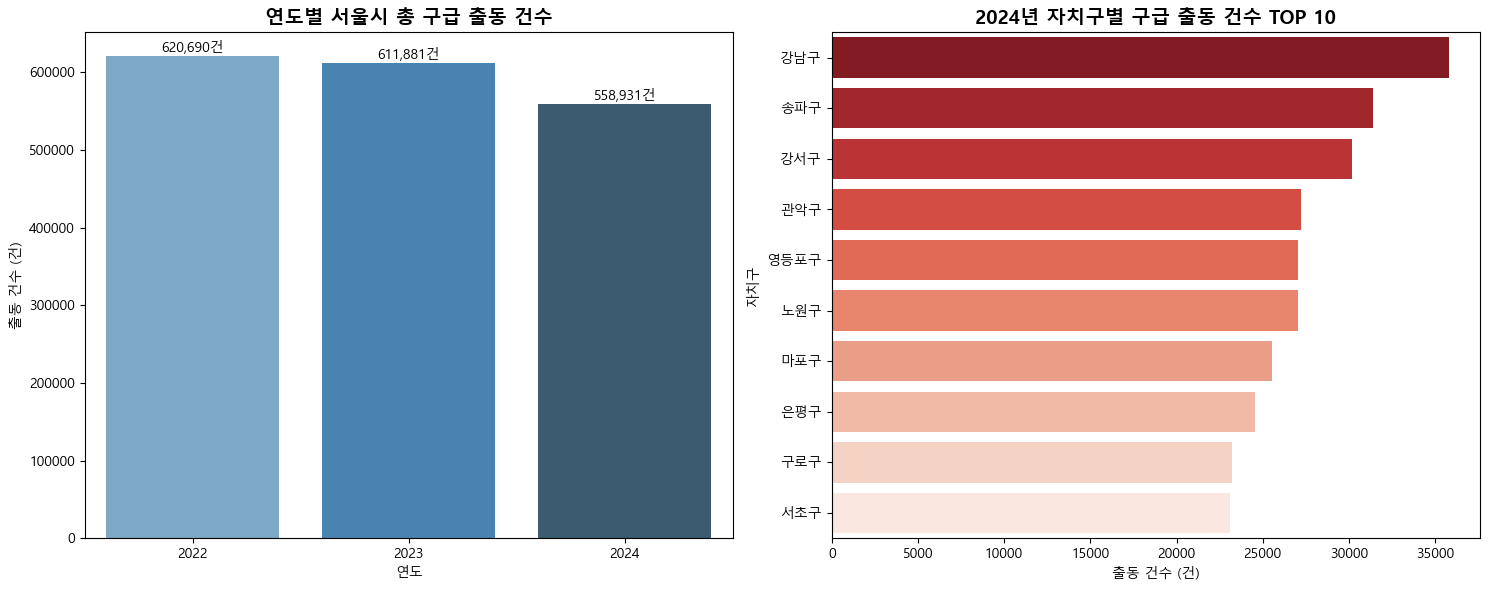

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 2. 원본 엑셀 파일 불러오기
file_path = r'C:\Users\mbc1\Desktop\서울시 소방 구급 출동 현황.xlsx'
xls = pd.ExcelFile(file_path)

seoul_gu_list = ['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', 
                 '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', 
                 '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']

processed_rows = []

# 3. 데이터 실시간 전처리
for sheet in xls.sheet_names:
    year = int(sheet.replace('년', ''))
    df = pd.read_excel(file_path, sheet_name=sheet)
    current_gu = None
    
    for idx, row in df.iterrows():
        gubun = str(row['구분']).strip()
        
        if gubun in seoul_gu_list:
            row_vals = row[['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']]
            sum_val = row_vals.dropna().sum()
            if sum_val > 500:
                current_gu = gubun
                is_district_sum = True
            else:
                is_district_sum = False
        else:
            is_district_sum = False
            
        for m in range(1, 13):
            val = row[f'{m}월']
            dispatch_cnt = 0 if pd.isna(val) or val == '' else float(val)
            
            processed_rows.append({
                '연도': year,
                '월': f'{m}월',
                '자치구': current_gu,
                '동_구분': gubun,
                '구분유형': '자치구합계' if is_district_sum else '동별상세',
                '출동건수': int(dispatch_cnt)
            })

df_tidy = pd.DataFrame(processed_rows)

# 4. 차트 생성 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# [차트 1] 연도별 총 출동 건수
df_detail = df_tidy[df_tidy['구분유형'] == '동별상세']
yearly_total = df_detail.groupby('연도')['출동건수'].sum().reset_index()

sns.barplot(data=yearly_total, x='연도', y='출동건수', palette='Blues_d', ax=axes[0])
axes[0].set_title('연도별 서울시 총 구급 출동 건수', fontsize=14, fontweight='bold')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('출동 건수 (건)')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}건', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 6), textcoords='offset points')

# [차트 2] 2024년 자치구별 출동 건수 TOP 10
df_gu = df_tidy[df_tidy['구분유형'] == '자치구합계']
rank_2024 = df_gu[df_gu['연도'] == 2024].groupby('자치구')['출동건수'].sum().reset_index()
rank_2024 = rank_2024.sort_values(by='출동건수', ascending=False).head(10)

sns.barplot(data=rank_2024, x='출동건수', y='자치구', palette='Reds_r', ax=axes[1])
axes[1].set_title('2024년 자치구별 구급 출동 건수 TOP 10', fontsize=14, fontweight='bold')
axes[1].set_xlabel('출동 건수 (건)')
axes[1].set_ylabel('자치구')

plt.tight_layout()
plt.show()